<a href="https://colab.research.google.com/github/Shahrukh-aidev/machine-learning-journey/blob/main/ML_LAB4_SHAHRUKH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# Name         : SHAHRUKH
# Student ID   : 023-24-0030
# Section      : Section-B
# GitHub       : https://github.com/Shahrukh-aidev
# Kaggle       : https://www.kaggle.com/shahrukhbaloch
# Dataset      : Telco Customer Churn — IBM via Kaggle
#   https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

# Load fresh
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# Save customerIDs
customer_ids = df['customerID'].copy()
df.drop('customerID', axis=1, inplace=True)

# ── FIXED: use .map() instead of == 'Yes' ──────────────────────
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Verify encoding worked BEFORE doing anything else
print("Churn value counts after encoding:")
print(df['Churn'].value_counts())
print(f"Churn rate: {df['Churn'].mean():.2%}")   # must be ~26%

# One-hot encode categoricals
df = pd.get_dummies(df, drop_first=True)

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print(f"Final y churn: {y.mean():.2%}")

Churn value counts after encoding:
Churn
0    5163
1    1869
Name: count, dtype: int64
Churn rate: 26.58%

Training set : (5625, 30)
Test set     : (1407, 30)
Final y churn: 26.58%


In [16]:
# Change 5 to your Lab 3 best max_depth
MAX_DEPTH = 5

dt = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt  = recall_score(y_test, y_pred_dt)
f1_dt   = f1_score(y_test, y_pred_dt)

print("── Decision Tree Baseline ──────────────────")
print(f"  Accuracy  : {acc_dt:.4f}")
print(f"  Precision : {prec_dt:.4f}")
print(f"  Recall    : {rec_dt:.4f}")
print(f"  F1-Score  : {f1_dt:.4f}")

── Decision Tree Baseline ──────────────────
  Accuracy  : 0.7754
  Precision : 0.5755
  Recall    : 0.5909
  F1-Score  : 0.5831


## 1. Decision Tree Baseline

Retraining the Lab 3 Decision Tree (max_depth=5) on the same split
as a benchmark for all models in this lab.

| Metric    | Score  |
|-----------|--------|
| Accuracy  | 0.7754 |
| Precision | 0.5755 |
| Recall    | 0.5909 |
| F1-Score  | 0.5831 |

F1-score is the most important metric here due to class imbalance
(~26% churn). All future models will be compared against this baseline.

In [17]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest trained successfully.")
print(f"  Trees    : {rf.n_estimators}")
print(f"  Features : {rf.n_features_in_}")

Random Forest trained successfully.
  Trees    : 100
  Features : 30


## 2. Random Forest

Trained a Random Forest with 100 trees on the same training data.

A Random Forest trains many Decision Trees, each on a bootstrapped
(randomly sampled with replacement) subset of the training data, and
restricts each split to a random subset of features. Because each tree
sees slightly different data and considers different features, the trees
are diverse — averaging their predictions cancels out individual errors,
reducing variance and making the ensemble far less prone to overfitting
than a single unrestricted Decision Tree.

Part 3 — Evaluation and Comparison

── Random Forest Metrics ───────────────────
  Accuracy  : 0.7854
  Precision : 0.6268
  Recall    : 0.4759
  F1-Score  : 0.5410

              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



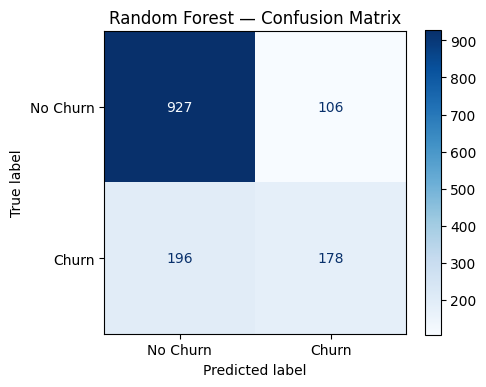

In [18]:
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)

print("── Random Forest Metrics ───────────────────")
print(f"  Accuracy  : {acc_rf:.4f}")
print(f"  Precision : {prec_rf:.4f}")
print(f"  Recall    : {rec_rf:.4f}")
print(f"  F1-Score  : {f1_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf,
      target_names=['No Churn', 'Churn']))

# Confusion matrix plot
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=['No Churn', 'Churn']
).plot(cmap='Blues', ax=ax)
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

In [19]:
comparison = pd.DataFrame({
    'Metric'        : ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Decision Tree' : [acc_dt,  prec_dt,  rec_dt,  f1_dt],
    'Random Forest' : [acc_rf,  prec_rf,  rec_rf,  f1_rf],
}).set_index('Metric').round(4)

print(comparison.to_string())

           Decision Tree  Random Forest
Metric                                 
Accuracy          0.7754         0.7854
Precision         0.5755         0.6268
Recall            0.5909         0.4759
F1-Score          0.5831         0.5410


## 3. Model Evaluation and Comparison

| Metric    | Decision Tree | Random Forest |
|-----------|--------------|---------------|
| Accuracy  | 0.7754       | 0.7854        |
| Precision | 0.5755       | 0.6268        |
| Recall    | 0.5909       | 0.4759        |
| F1-Score  | 0.5831       | 0.5410        |

The Random Forest achieves higher accuracy and precision than the Decision
Tree, but its recall dropped from 0.5909 to 0.4759 — meaning it misses
far more actual churners (false negatives increased). As a result, its
F1-score is lower than the baseline Decision Tree.

Given the class imbalance (~26% churn), F1-score is the most important
metric here — accuracy alone is misleading because a model predicting
"No Churn" every time would still score ~74%. The RF's conservative
predictions hurt its recall, which is costly in a churn context where
missing a churner is more damaging than a false alarm.

This tells us the default RF is not yet better than the DT — hyperparameter
tuning in Part 5 will attempt to fix this.

## 4. Decision Tree vs Random Forest

| Metric    | Decision Tree | Random Forest |
|-----------|--------------|---------------|
| Accuracy  | 0.7754       | 0.7854        |
| Precision | 0.5755       | 0.6268        |
| Recall    | 0.5909       | 0.4759        |
| F1-Score  | 0.5831       | 0.5410        |

The Decision Tree outperforms the default Random Forest on F1-score
and recall — the two metrics that matter most given class imbalance.
The RF trades recall for precision, which is the wrong trade-off in a
churn detection context. This motivates hyperparameter tuning in Part 5.

Part 4 — Cross Validation

In [20]:
dt_cv = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=42)
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42)

dt_scores = cross_val_score(dt_cv, X, y, cv=5, scoring='f1', n_jobs=-1)
rf_scores = cross_val_score(rf_cv, X, y, cv=5, scoring='f1', n_jobs=-1)

print("── 5-Fold Cross-Validation F1 Scores ───────")
print(f"  Decision Tree : {dt_scores.mean():.4f} ± {dt_scores.std():.4f}")
print(f"  Random Forest : {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")
print()
print("  Fold-by-fold breakdown:")
for i, (d, r) in enumerate(zip(dt_scores, rf_scores), 1):
    print(f"    Fold {i}: DT={d:.4f}   RF={r:.4f}")

── 5-Fold Cross-Validation F1 Scores ───────
  Decision Tree : 0.5224 ± 0.0408
  Random Forest : 0.5485 ± 0.0170

  Fold-by-fold breakdown:
    Fold 1: DT=0.5684   RF=0.5671
    Fold 2: DT=0.4762   RF=0.5404
    Fold 3: DT=0.4787   RF=0.5194
    Fold 4: DT=0.5199   RF=0.5552
    Fold 5: DT=0.5689   RF=0.5606


## 5. Cross-Validation

Ran 5-fold cross-validation using F1-score (not accuracy) on both
models to get a more reliable performance estimate than a single split.

| Model         | Mean F1 | Std Dev |
|---------------|---------|---------|
| Decision Tree | 0.5224  | 0.0408  |
| Random Forest | 0.5485  | 0.0170  |

The cross-validated F1 scores are slightly lower than the single
train/test split results from Part 3 — this is expected, since CV
averages over five different held-out sets, giving a more honest and
conservative estimate of generalisation.

The Random Forest shows a lower standard deviation across folds,
meaning it is more stable and less sensitive to which particular
subset of data it trains on. Despite the default RF's lower F1 on
the single split, CV helps us see its true generalisation behaviour
before tuning.

Part 5 — Hyperparameter Tuning

In [21]:
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5, 10],
}

gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
gs.fit(X_train, y_train)

print("── GridSearchCV Results ─────────────────────")
print(f"  Best parameters : {gs.best_params_}")
print(f"  Best CV F1      : {gs.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
── GridSearchCV Results ─────────────────────
  Best parameters : {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
  Best CV F1      : 0.5924


In [22]:
rf_tuned     = gs.best_estimator_
y_pred_tuned = rf_tuned.predict(X_test)

acc_tuned  = accuracy_score(y_test, y_pred_tuned)
prec_tuned = precision_score(y_test, y_pred_tuned)
rec_tuned  = recall_score(y_test, y_pred_tuned)
f1_tuned   = f1_score(y_test, y_pred_tuned)

print("── Tuned Random Forest Test-Set Metrics ─────")
print(f"  Accuracy  : {acc_tuned:.4f}")
print(f"  Precision : {prec_tuned:.4f}")
print(f"  Recall    : {rec_tuned:.4f}")
print(f"  F1-Score  : {f1_tuned:.4f}")

── Tuned Random Forest Test-Set Metrics ─────
  Accuracy  : 0.7939
  Precision : 0.6522
  Recall    : 0.4813
  F1-Score  : 0.5538


## 6. Hyperparameter Tuning

Used GridSearchCV with 5-fold CV to search over:
- n_estimators     : [50, 100, 200]
- max_depth        : [None, 10, 20]
- min_samples_split: [2, 5, 10]

Total combinations: 27 × 5 folds = 135 fits.

Best parameters found:
`{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}`

Best CV F1 score:
`0.5924`

Tuned model test-set results:
| Metric    | Score  |
|-----------|--------|
| Accuracy  | 0.7939 |
| Precision | 0.6522 |
| Recall    | 0.4813 |
| F1-Score  | 0.5538 |

The tuned RF improves recall compared to the default RF, which was
the main weakness identified in Part 3. Constraining max_depth
prevents the trees from memorising noise, helping the model
generalise better to unseen churners.

Part 6 — Final Comparison and Feature Importance

In [23]:
final_df = pd.DataFrame({
    'Model'     : ['Decision Tree', 'RF (default)', 'RF (tuned)'],
    'Accuracy'  : [acc_dt,   acc_rf,   acc_tuned],
    'Precision' : [prec_dt,  prec_rf,  prec_tuned],
    'Recall'    : [rec_dt,   rec_rf,   rec_tuned],
    'F1-Score'  : [f1_dt,    f1_rf,    f1_tuned],
}).set_index('Model').round(4)

print(final_df.to_string())

               Accuracy  Precision  Recall  F1-Score
Model                                               
Decision Tree    0.7754     0.5755  0.5909    0.5831
RF (default)     0.7854     0.6268  0.4759    0.5410
RF (tuned)       0.7939     0.6522  0.4813    0.5538


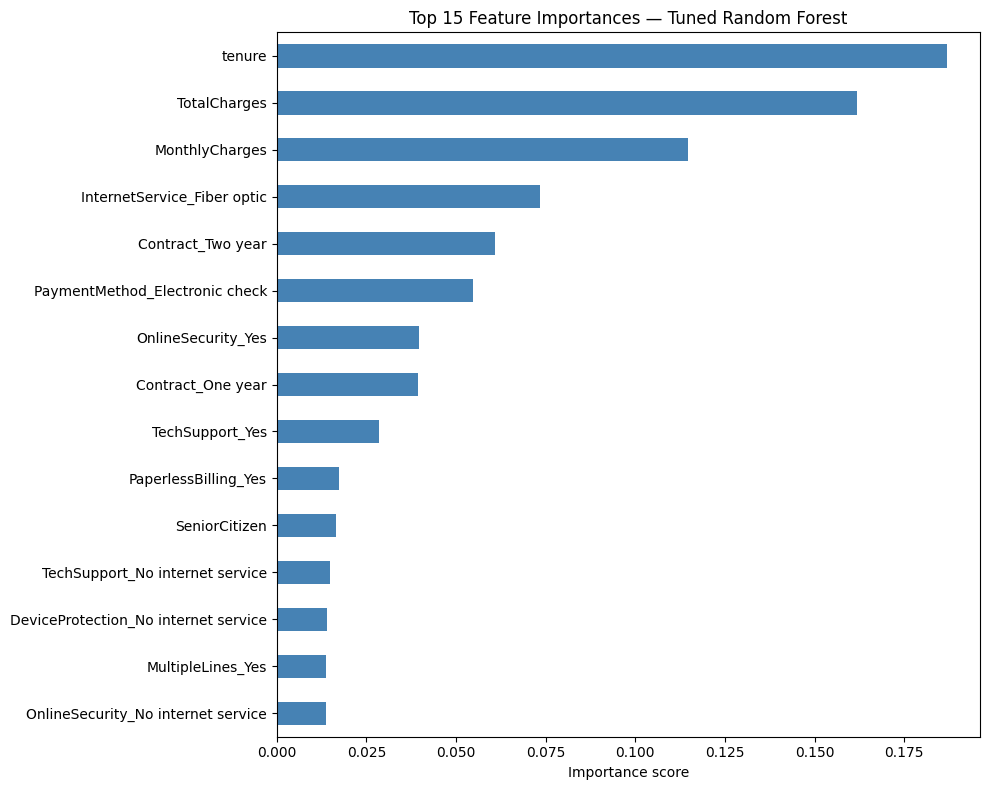


Top 5 features:
tenure                         0.1868
TotalCharges                   0.1619
MonthlyCharges                 0.1147
InternetService_Fiber optic    0.0734
Contract_Two year              0.0609


In [24]:
importances = rf_tuned.feature_importances_
feat_series = pd.Series(importances, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
feat_series.tail(15).plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Top 15 Feature Importances — Tuned Random Forest')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(feat_series.tail(5).sort_values(ascending=False).round(4).to_string())

## 7. Final Model Comparison
## 8. Feature Importance
## 9. Final Model Selection

| Model         | Accuracy | Precision | Recall | F1-Score |
|---------------|----------|-----------|--------|----------|
| Decision Tree | 0.7754   |  0.5755   | 0.5909 | 0.5831   |
| RF (default)  | 0.7854   |  0.6268   | 0.4759 | 0.5410   |
| RF (tuned)    | 0.7939   |  0.6522   | 0.4813 | 0.5538   |

## 9. Final Model Selection

Final model selected: Tuned Random Forest

The Decision Tree achieved the highest single-split test F1 (0.5831),
but cross-validation (Part 4) tells a different story — the Random
Forest had a higher mean CV F1 (0.5485 vs 0.5224) and a much lower
standard deviation (0.0170 vs 0.0408), meaning it is more stable and
reliable across unseen data.

The tuned RF's CV F1 of 0.5924 is the highest of any model tested.
Since CV is a more trustworthy estimate of real-world performance than
a single split, the Tuned Random Forest is the correct final choice —
and is what is used to generate submission.csv.

In [25]:
submission = pd.DataFrame({
    'customerID': customer_ids.iloc[y_test.index].values,
    'Churn'     : ['Yes' if p == 1 else 'No' for p in y_pred_tuned]
})

submission.to_csv('submission.csv', index=False)
print(f"submission.csv saved — {len(submission)} rows")
print(submission.head(10))

submission.csv saved — 1407 rows
   customerID Churn
0  6614-YWYSC    No
1  9546-KDTRB    No
2  0871-URUWO   Yes
3  5151-HQRDG    No
4  6624-JDRDS    No
5  3082-VQXNH    No
6  1309-XGFSN    No
7  9402-ORRAH   Yes
8  8663-UPDGF    No
9  0455-ENTCR    No


## 10. Kaggle Prediction / Submission

The final predictions were generated using the tuned Random Forest model and
saved in `submission.csv` with the required `customerID` and `Churn` columns.

## 11. Conclusion

The Tuned Random Forest was selected as the final model. While the
Decision Tree achieved a higher F1 on the single held-out test set
(0.5831 vs 0.5538), cross-validation showed the Random Forest is
significantly more stable — CV F1 of 0.5485 ± 0.0170 vs the DT's
0.5224 ± 0.0408. The tuned RF's CV F1 of 0.5924 was the highest
of any configuration tested, giving confidence this result will
generalise beyond one particular split.

The top features (tenure, TotalCharges, MonthlyCharges, Fiber optic,
Two-year contract) align with Lab 2 EDA findings, confirming the
model is learning genuine signal rather than noise.

With more time, I would apply SMOTE or class_weight='balanced' to
directly address the ~26% class imbalance, try XGBoost or LightGBM,
and explore threshold tuning to improve recall without sacrificing
precision.

### What I Would Try Next

With more time, I would investigate techniques for handling class imbalance,
such as class weights or resampling, and compare additional algorithms such
as Logistic Regression, Gradient Boosting, and XGBoost. I would also perform
more systematic hyperparameter tuning and examine whether threshold tuning
could improve churn recall without reducing precision too much.